Connected to base (Python 3.13.5)

 # Data Mining Techniques — Assignment 1
 ## Mood Smartphone Dataset (Advanced)

 ## Imports

In [1]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

import joblib

os.makedirs("figures", exist_ok=True) # create models and figures directories if they don't exist
os.makedirs("models",  exist_ok=True)

 ## Plot style

In [2]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

 ---
 ## 1A - Exploratory Data Analysis

In [3]:
df = pd.read_csv("dataset_mood_smartphone.csv")
df["time"] = pd.to_datetime(df["time"])
df["date"] = pd.to_datetime(df["time"].dt.date)
df["hour"] = df["time"].dt.hour

print("Shape              :", df.shape)
print("Date range         :", df["time"].min().date(), "→", df["time"].max().date())
print("Unique users       :", df["id"].nunique())
print("Unique variables   :", df["variable"].nunique())
print("Missing values     :", df["value"].isnull().sum())

Shape              : (376912, 7)
Date range         : 2014-02-17 → 2014-06-09
Unique users       : 27
Unique variables   : 19
Missing values     : 202


In [4]:
# Per-variable statistics table
grouped = df.groupby("variable")["value"]
total   = grouped.count()
missing = grouped.size() - grouped.count()
missing_pct = (missing / (missing + total) * 100).round(1)

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"]   = missing
stats["missing %"] = missing_pct.fillna(100.0)
stats

,count,mean,std,min,25%,median,75%,max,missing,missing %
variable,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0


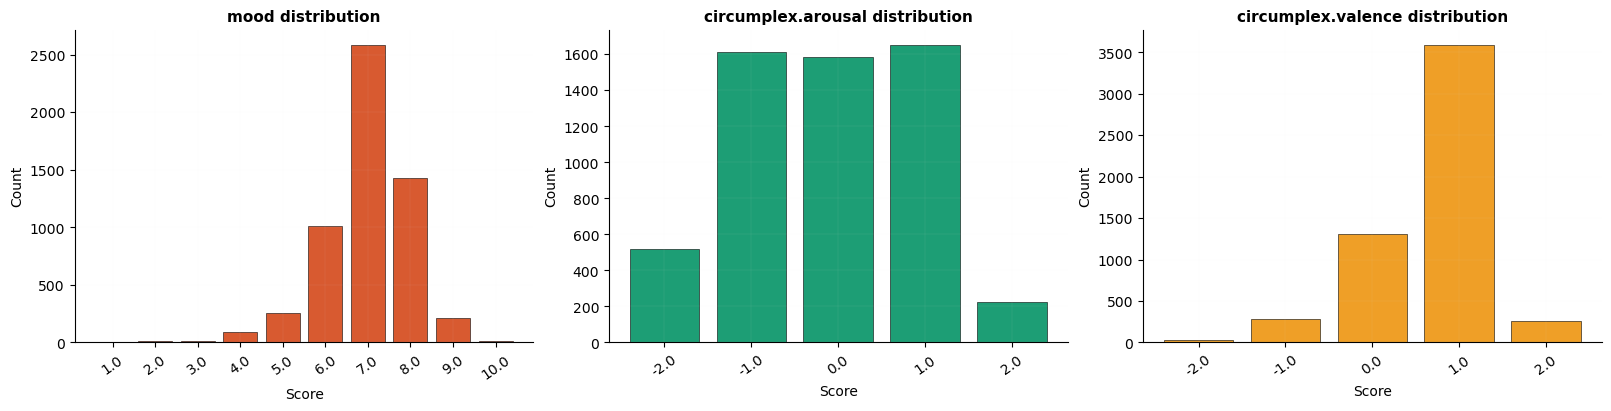

In [5]:
# Distribution of self-report variables
cat_vars = ["mood", "circumplex.arousal", "circumplex.valence"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, var, color in zip(axes, cat_vars, [CORAL, TEAL, AMBER]):
    vals   = df.loc[df["variable"].eq(var), "value"].dropna()
    counts = vals.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)
    ax.set_title(f"{var} distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35)

plt.savefig("figures/eda_self_reports.png", dpi=150, bbox_inches="tight")
plt.show()

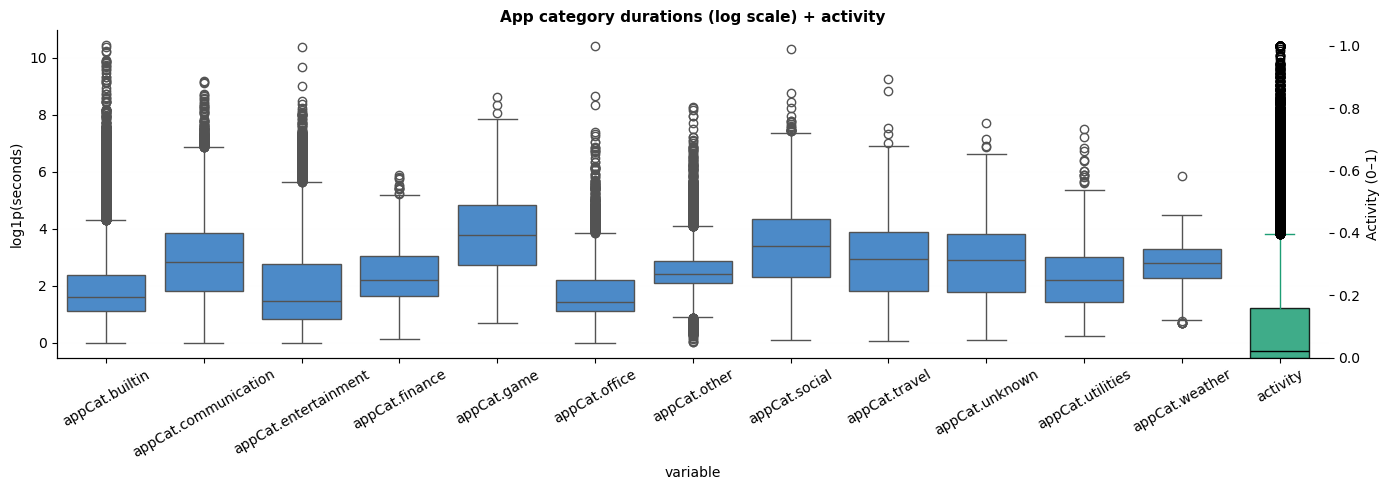

In [6]:
# App categories boxplot (log scale) + activity on twin axis
appcat_data   = df[df["variable"].str.startswith("appCat.") & df["value"].notna() & (df["value"] >= 0)].copy()
activity_data = df[df["variable"].eq("activity") & df["value"].notna() & (df["value"] >= 0)].copy()
appcat_data["log_value"] = np.log1p(appcat_data["value"])
appcat_order  = sorted(appcat_data["variable"].unique())

fig, ax1 = plt.subplots(figsize=(14, 5))
sns.boxplot(data=appcat_data, x="variable", y="log_value",
            order=appcat_order, color=BLUE, ax=ax1)
ax1.set_ylabel("log1p(seconds)")
ax1.set_title("App category durations (log scale) + activity")

ax2 = ax1.twinx()
ax2.boxplot([activity_data["value"].values],
            positions=[len(appcat_order)], widths=0.6, patch_artist=True,
            boxprops=dict(facecolor=TEAL, alpha=0.85),
            medianprops=dict(color="black"),
            whiskerprops=dict(color=TEAL), capprops=dict(color=TEAL))
ax2.set_ylabel("Activity (0–1)")
ax2.set_ylim(0, 1.05)
ax2.grid(False)

ax1.set_xticks(list(range(len(appcat_order))) + [len(appcat_order)])
ax1.set_xticklabels(appcat_order + ["activity"], rotation=30)
ax1.set_xlim(-0.5, len(appcat_order) + 0.5)

plt.tight_layout()
plt.savefig("figures/eda_appcat_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

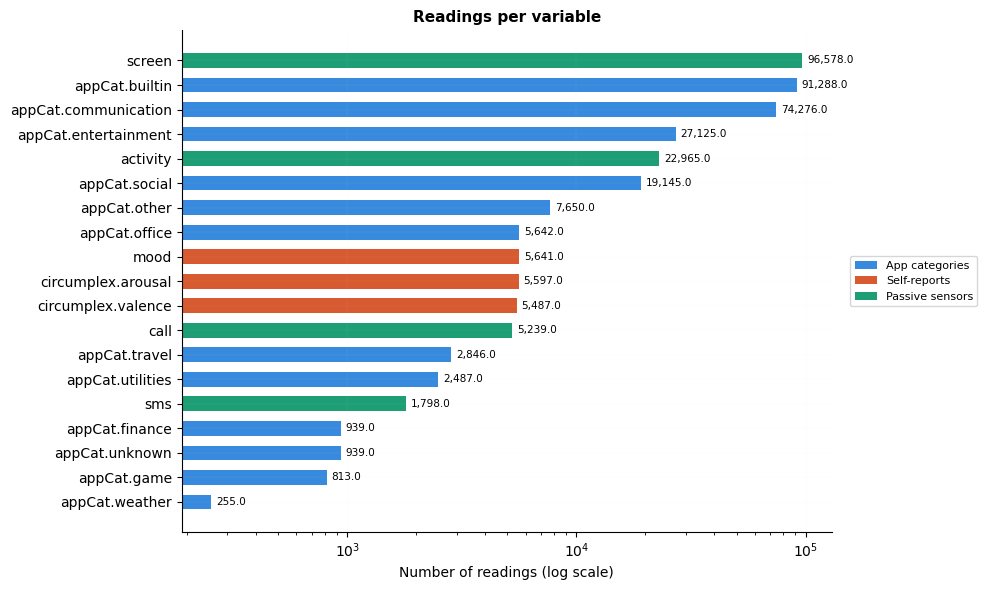

In [7]:
# Variable record counts (log scale)
counts     = stats["count"].sort_values(ascending=True)
colors_bar = [BLUE if "appCat" in v else
              CORAL if v in ("mood","circumplex.arousal","circumplex.valence") else
              TEAL for v in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(counts.index, counts.values, height=0.6, color=colors_bar)
ax.set_xscale("log")
ax.set_xlabel("Number of readings (log scale)")
ax.set_title("Readings per variable")
ax.legend(handles=[
    mpatches.Patch(facecolor=BLUE,  label="App categories"),
    mpatches.Patch(facecolor=CORAL, label="Self-reports"),
    mpatches.Patch(facecolor=TEAL,  label="Passive sensors"),
], fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
for v, var in zip(counts.values, counts.index):
    ax.text(v * 1.05, var, f"{v:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.savefig("figures/eda_variable_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Circumplex missing value analysis
for var in ["circumplex.arousal", "circumplex.valence"]:
    sub   = df[df["variable"] == var].copy()
    daily = sub.groupby(["id", "date"])["value"].agg(
        total_rows="size",
        missing_rows=lambda s: s.isna().sum(),
        present_rows=lambda s: s.notna().sum(),
    )
    missing_only = daily[(daily["missing_rows"] > 0) & (daily["present_rows"] == 0)]
    print(f"{var}: {daily['missing_rows'].gt(0).sum()} days with ≥1 missing row")
    print(f"         {len(missing_only)} days fully missing → will be imputed")

circumplex.arousal: 45 days with ≥1 missing row
         0 days fully missing → will be imputed
circumplex.valence: 119 days with ≥1 missing row
         2 days fully missing → will be imputed


## 1B - Data Cleaning

In [6]:
# Remove negative values (physically impossible durations)
for var in ["appCat.builtin", "appCat.entertainment"]:
    neg = (df["variable"].eq(var)) & (df["value"] < 0)
    print(f"Removing {neg.sum()} negative rows from {var}")
    df  = df.loc[~neg].copy()

Removing 3 negative rows from appCat.builtin
Removing 1 negative rows from appCat.entertainment


In [7]:
# Pivot to wide format
# Self-reports + activity: mean/max/min/std/count per day
mood_data  = df[df["variable"].isin(
    ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
)].sort_values(["id", "time"])

mood_pivot = mood_data.pivot_table(
    index=["id", "date"], columns="variable", values="value",
    aggfunc=["mean", "max", "min", "std", "count"]
)
mood_pivot.columns = [f"{var}_{stat}" for stat, var in mood_pivot.columns]
mood_pivot = mood_pivot.reset_index()

# Recorded variables: sum per day
rec_vars = ["screen", "call", "sms",
            "appCat.builtin", "appCat.communication", "appCat.entertainment",
            "appCat.finance", "appCat.game", "appCat.office", "appCat.other",
            "appCat.social", "appCat.travel", "appCat.unknown",
            "appCat.utilities", "appCat.weather"]

rec_pivot = df[df["variable"].isin(rec_vars)].sort_values(["id", "time"]).pivot_table(
    index=["id", "date"], columns="variable", values="value", aggfunc=["sum"]
)
rec_pivot.columns = [f"{var}_{stat}" for stat, var in rec_pivot.columns]
rec_pivot = rec_pivot.reset_index()

df_wide = mood_pivot.merge(rec_pivot, on=["id", "date"], how="outer")
df_wide["day_of_week"] = df_wide["date"].dt.day_name()
df_wide["month"]       = df_wide["date"].dt.month_name()
df_wide["weekend"]     = df_wide["day_of_week"].isin(["Saturday", "Sunday"])
print("Wide shape:", df_wide.shape)

Wide shape: (1973, 40)


In [9]:
# Gap analysis — find users with gaps > 3 days in mood recordings
gap_threshold = 3
results_gap   = []
for pid, grp in df_wide.groupby("id"):
    valid = grp[grp["mood_mean"].notna()].sort_values("date")
    valid = valid.copy()
    valid["gap_days"] = valid["date"].diff().dt.days
    big   = valid[valid["gap_days"] > gap_threshold][["date", "gap_days"]]
    if not big.empty:
        big["id"] = pid
        results_gap.append(big)

if results_gap:
    print(pd.concat(results_gap).sort_values(["id", "date"]).to_string())

          date  gap_days       id
26  2014-03-21      22.0  AS14.01
576 2014-03-27      12.0  AS14.12
942 2014-03-21       7.0  AS14.17


In [10]:
# Remove data before prolonged gaps (keep only the most recent consecutive block)
result = []
for pid, grp in df_wide.groupby("id"):
    grp         = grp.sort_values("date")
    valid_dates = grp[grp["mood_mean"].notna()]["date"]
    gaps        = valid_dates.diff()
    big_gap_dates = valid_dates[gaps.dt.days > gap_threshold]
    if not big_gap_dates.empty:
        cutoff   = big_gap_dates.iloc[-1]
        n_before = (grp["date"] < cutoff).sum()
        grp      = grp[grp["date"] >= cutoff]
        print(f"User {pid}: removed {n_before} days before {cutoff.date()}")
    result.append(grp)

df_consec = pd.concat(result, ignore_index=True)
print("Shape after gap removal:", df_consec.shape)

User AS14.01: removed 26 days before 2014-03-21
User AS14.12: removed 27 days before 2014-03-27
User AS14.17: removed 29 days before 2014-03-21
Shape after gap removal: (1891, 40)


In [18]:
# Resample to one row per user per day (fills in missing calendar days)
df_daily = (
    df_consec.set_index("date")
    .groupby("id")
    .resample("D").asfreq()
    .reset_index()
).copy()

print("Shape after resampling:", df_daily.shape)
print("NaNs per column:\n", df_daily.isna().sum().to_string())

Shape after resampling: (2054, 40)
NaNs per column:
 id                             0
date                           0
activity_mean                868
circumplex.arousal_mean      800
circumplex.valence_mean      802
mood_mean                    800
activity_max                 868
circumplex.arousal_max       800
circumplex.valence_max       802
mood_max                     800
activity_min                 868
circumplex.arousal_min       800
circumplex.valence_min       802
mood_min                     800
activity_std                 878
circumplex.arousal_std       825
circumplex.valence_std       829
mood_std                     825
activity_count               868
circumplex.arousal_count     800
circumplex.valence_count     800
mood_count                   800
appCat.builtin_sum           861
appCat.communication_sum     873
appCat.entertainment_sum    1206
appCat.finance_sum          1847
appCat.game_sum             1861
appCat.office_sum           1778
appCat.other_sum       

In [19]:
# Zero-fill for app categories, screen, call, sms
# (NaN = not used that day — not a true missing value)
zero_cols = [c for c in df_daily.columns
             if c.startswith("appCat") or c in
             ["screen_sum", "call_sum", "sms_sum"]]
df_daily[zero_cols] = df_daily[zero_cols].fillna(0)
print("NaNs after zero-fill:", df_daily[zero_cols].isna().sum().sum())

NaNs after zero-fill: 0


In [20]:
# Imputation for self-report variables
# target_vars covers all daily aggregation columns (mean/max/min/std/count)
target_vars = [c for c in df_daily.columns
               if any(s in c for s in ["mean","max","min","std"])]

# zero-fill counts separately
count_cols = [c for c in df_daily.columns if c.endswith("_count")]
df_daily[count_cols] = df_daily[count_cols].fillna(0)

# Method 1: LOCF — last observation carried forward (limit 3 days)
df_LOCF = df_daily.copy().sort_values(["id", "date"])
for var in target_vars:
    df_LOCF[var] = df_LOCF.groupby("id")[var].ffill(limit=3)

# Method 2: Linear interpolation (limit 3 days forward)
df_interpolation = df_daily.copy().sort_values(["id", "date"])
for var in target_vars:
    df_interpolation[var] = df_interpolation.groupby("id")[var].transform(
        lambda x: x.interpolate(method="linear", limit=3, limit_direction="forward")
    )

print("NaNs after LOCF:")
print(df_LOCF[target_vars].isna().sum()[df_LOCF[target_vars].isna().sum() > 0])
print("\nNaNs after interpolation:")
print(df_interpolation[target_vars].isna().sum()[df_interpolation[target_vars].isna().sum() > 0])

NaNs after LOCF:
activity_mean              840
circumplex.arousal_mean    765
circumplex.valence_mean    765
mood_mean                  765
activity_max               840
circumplex.arousal_max     765
circumplex.valence_max     765
mood_max                   765
activity_min               840
circumplex.arousal_min     765
circumplex.valence_min     765
mood_min                   765
activity_std               842
circumplex.arousal_std     772
circumplex.valence_std     772
mood_std                   772
dtype: int64

NaNs after interpolation:
activity_mean              840
circumplex.arousal_mean    765
circumplex.valence_mean    765
mood_mean                  765
activity_max               840
circumplex.arousal_max     765
circumplex.valence_max     765
mood_max                   765
activity_min               840
circumplex.arousal_min     765
circumplex.valence_min     765
mood_min                   765
activity_std               842
circumplex.arousal_std     772
circumplex.va

In [21]:
# Drop rows where mood is still missing
df_LOCF          = df_LOCF.dropna(subset=["mood_mean"])
df_interpolation = df_interpolation.dropna(subset=["mood_mean"])
print("LOCF shape          :", df_LOCF.shape)
print("Interpolation shape :", df_interpolation.shape)

LOCF shape          : (1289, 40)
Interpolation shape : (1289, 40)


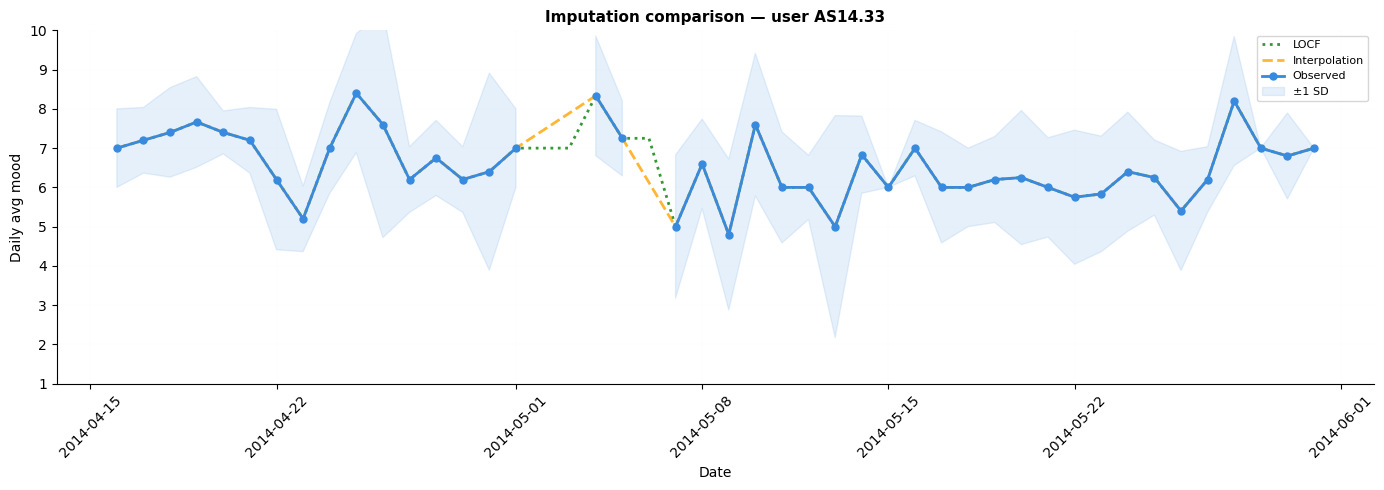

In [22]:
# Imputation comparison plot — select a user with visible gaps
user_sel  = "AS14.33"
df_orig   = df_wide[df_wide["id"] == user_sel]
df_locf   = df_LOCF[df_LOCF["id"] == user_sel]
df_interp = df_interpolation[df_interpolation["id"] == user_sel]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_locf["date"],  df_locf["mood_mean"],
        color="green",  ls=":", lw=2, alpha=0.8, label="LOCF")
ax.plot(df_interp["date"], df_interp["mood_mean"],
        color="orange", ls="--", lw=2, alpha=0.8, label="Interpolation")
ax.plot(df_orig["date"],  df_orig["mood_mean"],
        color=BLUE, marker="o", ms=5, lw=2, label="Observed")
ax.fill_between(df_orig["date"],
                df_orig["mood_mean"] - df_orig["mood_std"].fillna(0),
                df_orig["mood_mean"] + df_orig["mood_std"].fillna(0),
                color=BLUE, alpha=0.12, label="±1 SD")
ax.set_ylim(1, 10)
ax.set_title(f"Imputation comparison — user {user_sel}")
ax.set_xlabel("Date"); ax.set_ylabel("Daily avg mood")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/imputation_comparison.png", dpi=150)
plt.show()

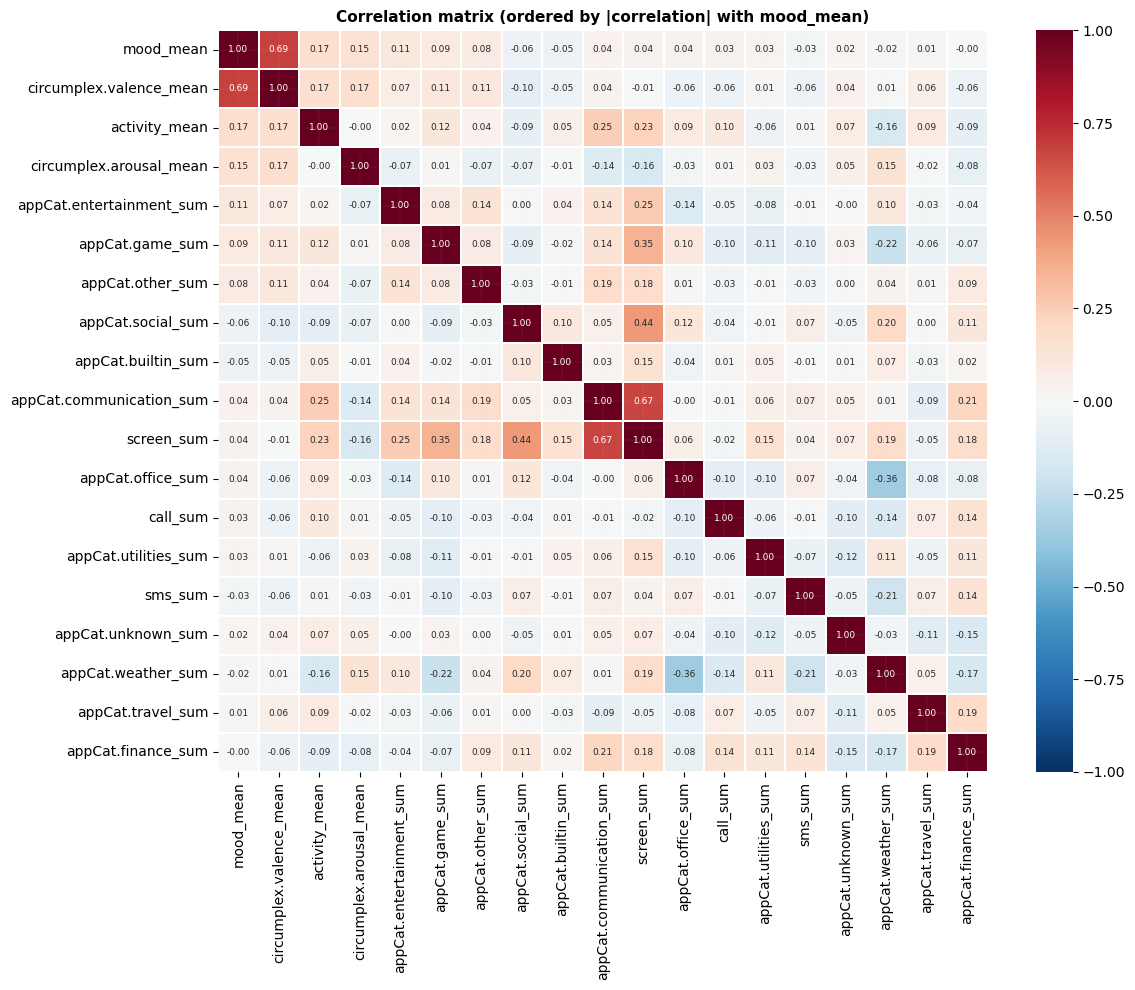

In [18]:
# Correlation matrix (ordered by correlation with mood_mean)
cols_corr = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean",
             "activity_mean"] + [c for c in df_wide.columns if c.endswith("_sum")]
cols_corr = [c for c in cols_corr if c in df_wide.columns]

corr  = df_wide[cols_corr].corr()
order = corr["mood_mean"].abs().sort_values(ascending=False).index
corr  = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 6.5}, ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
plt.tight_layout()
plt.savefig("figures/correlation_matrix.png", dpi=150)
plt.show()

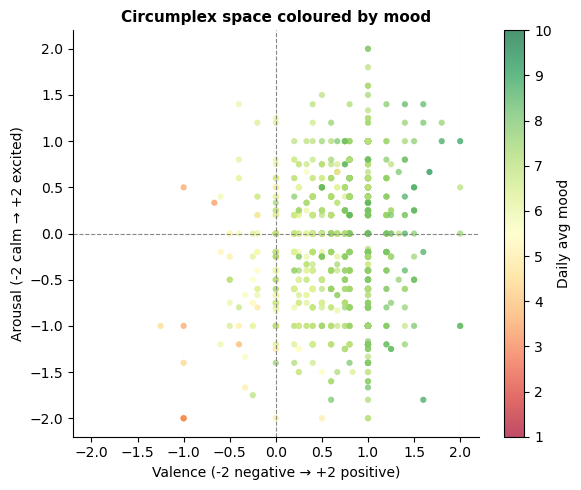

In [19]:
# Circumplex scatter coloured by mood
circ = df_wide[["circumplex.valence_mean","circumplex.arousal_mean","mood_mean"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence_mean"], circ["circumplex.arousal_mean"],
                c=circ["mood_mean"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, s=20, linewidths=0)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
ax.axhline(0, color=GRAY, lw=0.8, ls="--")
ax.axvline(0, color=GRAY, lw=0.8, ls="--")
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
ax.set_xlabel("Valence (-2 negative → +2 positive)")
ax.set_ylabel("Arousal (-2 calm → +2 excited)")
ax.set_title("Circumplex space coloured by mood")
plt.tight_layout()
plt.savefig("figures/circumplex_scatter.png", dpi=150)
plt.show()

## 1C - Feature Engineering

In [23]:
# Use interpolation as final cleaned dataset (best imputation method)
df_feature = df_interpolation.copy()
df_feature = df_feature.rename(columns={
    "circumplex.arousal_mean": "arousal_mean",
    "circumplex.valence_mean": "valence_mean",
})
df_feature = df_feature.sort_values(["id", "date"]).reset_index(drop=True)

# Weekend flag + day/month dummies
df_feature["day_of_week"] = df_feature["date"].dt.day_name()
df_feature["month"]       = df_feature["date"].dt.month_name()
df_feature["weekend"]     = df_feature["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

day_dummies   = pd.get_dummies(df_feature["day_of_week"], dtype=int).drop(columns="Sunday") # dummy trap?
month_dummies = pd.get_dummies(df_feature["month"],       dtype=int).drop(columns="March")
df_feature    = pd.concat([df_feature, day_dummies, month_dummies], axis=1)

days   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
months = ["April","May","June"]

In [24]:
# Normalised app-usage histogram (proportion of total app time per day)
only_apps = [c for c in df_feature.columns if c.endswith("_sum") and "appCat" in c]
df_feature["total_app_time"] = df_feature[only_apps].sum(axis=1).replace(0, np.nan)

for col in only_apps:
    df_feature[col.replace("_sum","_hist")] = df_feature[col] / df_feature["total_app_time"]

hist_appcat_cols = [c for c in df_feature.columns if c.endswith("_hist")]
df_feature[hist_appcat_cols] = df_feature[hist_appcat_cols].fillna(0)

print("df_feature shape:", df_feature.shape)

df_feature shape: (1289, 62)


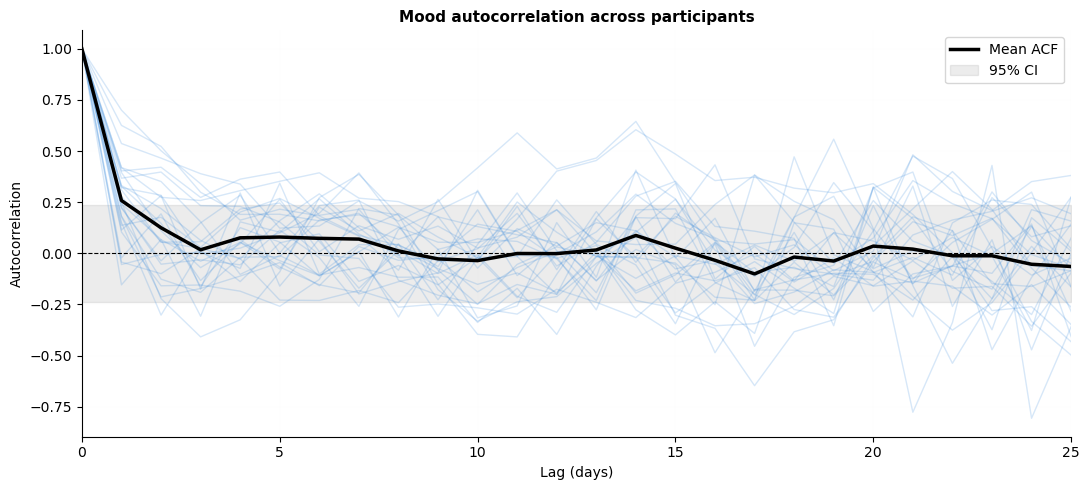

In [30]:
# ACF plot — could justify window size choice
max_lag  = 25
acf_rows = []
incl_ids = []

for pid, grp in df_interpolation.groupby("id"):
    s = grp.sort_values("date")["mood_mean"].dropna().reset_index(drop=True)
    if len(s) <= max_lag:
        continue
    acf_rows.append([1.0] + [s.autocorr(lag=k) for k in range(1, max_lag+1)])
    incl_ids.append(pid)

acf_mat  = np.array(acf_rows)
mean_acf = np.nanmean(acf_mat, axis=0)
lags     = np.arange(max_lag + 1)

max_n = max(len(df_interpolation.loc[df_interpolation["id"]==pid,"mood_mean"].dropna())
            for pid in incl_ids)
ci    = 1.96 / np.sqrt(max_n)

fig, ax = plt.subplots(figsize=(11, 5))
for row in acf_mat:
    ax.plot(lags, row, color=BLUE, alpha=0.2, lw=1)
ax.plot(lags, mean_acf, color="black", lw=2.5, label="Mean ACF")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.fill_between(lags, -ci, ci, color="gray", alpha=0.15, label="95% CI")
ax.set_title("Mood autocorrelation across participants")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Autocorrelation")
ax.set_xlim(0, max_lag); ax.legend()
plt.tight_layout()
plt.savefig("figures/mood_acf.png", dpi=150)
plt.show()

In [25]:
# Windowing loop — builds one training instance per user-day
# Features: aggregations over past `window` days
# Target:   mood on day t (= next day relative to the window)

window     = 5
mood_cols  = ["mood_mean", "arousal_mean", "valence_mean", "activity_mean"]
appcat_sum_cols  = [c for c in df_feature.columns if c.endswith("_sum")] + ["total_app_time"]
appcat_hist_cols = [c for c in df_feature.columns if c.endswith("_hist")]

instances = []   # defined immediately before loop — avoids accumulation on re-run

for patient_id, group in df_feature.groupby("id"):
    group = group.reset_index(drop=True)

    for t in range(window, len(group)):
        win   = group.iloc[t - window : t]   # history: days t-W … t-1
        t_day = group.iloc[t]                # prediction day

        row = {"id": patient_id, "date": t_day["date"]}

        # ── mood/arousal/valence/activity: full stats + slope + ema ──────
        for col in mood_cols:
            name = col.replace("_mean", "")
            vals = win[col].values
            row[f"{name}_mean_{window}d"] = np.nanmean(vals)
            row[f"{name}_std_{window}d"]  = np.nanstd(vals)
            row[f"{name}_min_{window}d"]  = np.nanmin(vals)
            row[f"{name}_max_{window}d"]  = np.nanmax(vals)

            # slope — safe against NaN values in window
            mask = ~np.isnan(vals)
            if mask.sum() >= 2:
                row[f"{name}_slope_{window}d"] = np.polyfit(
                    np.arange(window)[mask], vals[mask], 1)[0]
            else:
                row[f"{name}_slope_{window}d"] = np.nan

            # exponential moving average (more weight to recent days)
            row[f"{name}_ema_{window}d"] = (
                win[col].ewm(span=window, adjust=False).mean().iloc[-1])

        # ── app category sums: mean + sum over window ────────────────────
        for col in appcat_sum_cols: # also total app time
            name = col.replace("appCat.", "appCat_").replace("_sum", "")
            row[f"{name}_mean_{window}d"] = win[col].mean()
            row[f"{name}_sum_{window}d"]  = win[col].sum()

        # ── app category hist: mean proportion over window ───────────────
        for col in appcat_hist_cols:
            name = col.replace("appCat.", "appCat_").replace("_hist", "")
            row[f"{name}_hist_mean_{window}d"] = win[col].mean()

        # ── temporal features for the prediction day ─────────────────────
        for d in days:
            row[d] = int(t_day.get(d, 0))
        for m in months:
            row[m] = int(t_day.get(m, 0))
        row["weekend"] = int(t_day["weekend"])

        row["target_mood"] = t_day["mood_mean"]
        instances.append(row)

df_ml = pd.DataFrame(instances).reset_index(drop=True)
print("df_ml shape:", df_ml.shape)
print("Columns:", len(df_ml.columns))
df_ml.head()

df_ml shape: (1154, 81)
Columns: 81


,id,date,mood_mean_5d,mood_std_5d,mood_min_5d,mood_max_5d,mood_slope_5d,mood_ema_5d,arousal_mean_5d,arousal_std_5d,...,Tuesday,Wednesday,Thursday,Friday,Saturday,April,May,June,weekend,target_mood
0,AS14.01,2014-03-26,6.43,0.309192,6.0,6.8,0.070,6.447531,0.46,0.233238,...,0,1,0,0,0,0,0,0,0,6.6
1,AS14.01,2014-03-27,6.51,0.290517,6.0,6.8,0.035,6.524691,0.38,0.348712,...,0,0,1,0,0,0,0,0,0,7.0
2,AS14.01,2014-03-28,6.63,0.340000,6.0,7.0,0.100,6.735802,0.30,0.334664,...,0,0,0,1,0,0,0,0,0,6.4
3,AS14.01,2014-03-29,6.55,0.337639,6.0,7.0,0.105,6.518519,0.14,0.496387,...,0,0,0,0,1,0,0,0,1,8.0
4,AS14.01,2014-03-30,6.95,0.560357,6.4,8.0,0.230,7.111111,0.02,0.381576,...,0,0,0,0,0,0,0,0,1,7.5


## 2A - Classification
### Class definition (quantile-based for balanced classes)

33rd pct: 6.80  |  66th pct: 7.25
mood_class
0    435
1    349
2    370
Name: count, dtype: int64
mood_class
0    0.376950
1    0.302426
2    0.320624
Name: count, dtype: float64


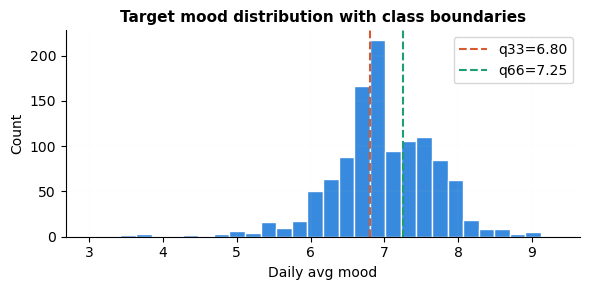

In [26]:
q33 = df_ml["target_mood"].quantile(0.33)
q66 = df_ml["target_mood"].quantile(0.66)
print(f"33rd pct: {q33:.2f}  |  66th pct: {q66:.2f}")

df_ml["mood_class"] = pd.cut(
    df_ml["target_mood"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

class_names = ["Low mood", "Neutral mood", "High mood"]

counts = df_ml["mood_class"].value_counts().sort_index()
print(counts)
print(counts / len(df_ml))

# target distribution plot
fig, ax = plt.subplots(figsize=(6, 3))
df_ml["target_mood"].hist(bins=30, color=BLUE, edgecolor="white", ax=ax)
ax.axvline(q33, color=CORAL, ls="--", lw=1.5, label=f"q33={q33:.2f}")
ax.axvline(q66, color=TEAL,  ls="--", lw=1.5, label=f"q66={q66:.2f}")
ax.set_xlabel("Daily avg mood"); ax.set_ylabel("Count")
ax.set_title("Target mood distribution with class boundaries")
ax.legend()
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=150)
plt.show()

In [27]:
# Fix: build from df_ml columns, not df_feature
X = df_ml.drop(columns=["id", "date", "target_mood", "mood_class"])
y = df_ml["mood_class"]

sum_cols     = [c for c in X.columns if c.startswith("appCat_") and "_sum_" in c]
hist_cols    = [c for c in X.columns if c.endswith("_hist_mean_5d")] + ["total_app_time_sum_5d", "total_app_time_mean_5d"]
base_non_app = [c for c in X.columns if not c.startswith("appCat_")]

FEATURE_SETS_XGB = {
    "only_sum":  list(dict.fromkeys(base_non_app + sum_cols)),
    "only_hist": list(dict.fromkeys(base_non_app + hist_cols)),
}

In [28]:
# Define train / test split — temporal, per patient (80% train / 20% test)
train_idx, test_idx = [], []
for pid, grp in df_ml.groupby("id"):
    grp   = grp.sort_values("date")
    split = int(len(grp) * 0.8)
    train_idx.extend(grp.index[:split].tolist())
    test_idx.extend(grp.index[split:].tolist())

X_train_full = X.loc[train_idx]
X_test       = X.loc[test_idx]
y_train_full = y.loc[train_idx]
y_test       = y.loc[test_idx]

print(f"Train: {len(y_train_full)}  |  Test: {len(y_test)}")
print("Train class balance:", y_train_full.value_counts(normalize=True).round(2).to_dict())

Train: 909  |  Test: 245
Train class balance: {0: 0.38, 2: 0.32, 1: 0.3}


In [32]:
# Helper: group-aware time-series CV split (defined once, reused everywhere)
def group_time_series_split(groups, n_splits=5):
    folds_train = [[] for _ in range(n_splits)]
    folds_val   = [[] for _ in range(n_splits)]
    for pid in np.unique(groups):
        p_idx = np.where(groups == pid)[0]
        for fi, (tr, val) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(p_idx)):
            folds_train[fi].extend(p_idx[tr])
            folds_val[fi].extend(p_idx[val])
    for fi in range(n_splits):
        yield np.array(folds_train[fi]), np.array(folds_val[fi])

 ### a) XGBoost classifier

In [33]:
# Baseline (default parameters, evaluated on train, using ALL features — starting point only)
sample_weights_full = compute_sample_weight("balanced", y=y_train_full)

scaler_base      = StandardScaler() # do we need it?
X_train_base_sc  = scaler_base.fit_transform(X_train_full)
X_test_base_sc   = scaler_base.transform(X_test)

baseline_xgb = xgb.XGBClassifier(
    objective="multi:softmax", num_class=3,
    eval_metric="mlogloss", random_state=1
)
baseline_xgb.fit(X_train_base_sc, y_train_full, sample_weight=sample_weights_full)
y_base_pred = baseline_xgb.predict(X_train_base_sc)
print("── Baseline (train set) ──")
print(classification_report(y_train_full, y_base_pred, target_names=class_names))

── Baseline (train set) ──
              precision    recall  f1-score   support

    Low mood       1.00      1.00      1.00       348
Neutral mood       1.00      1.00      1.00       272
   High mood       1.00      1.00      1.00       289

    accuracy                           1.00       909
   macro avg       1.00      1.00      1.00       909
weighted avg       1.00      1.00      1.00       909



In [34]:
# Randomized hyperparameter search with group-aware temporal CV
groups_train = df_ml.loc[train_idx, "id"].values
custom_cv    = list(group_time_series_split(groups_train, n_splits=5))

param_grid_xgb = {
    "model__max_depth":     [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators":  [100, 200, 300, 500],
    "model__subsample":     [0.8, 1.0],
}

results_xgb = {}

for name, feat_cols in FEATURE_SETS_XGB.items():
    print(f"\n{'='*60}\n XGBoost — {name}  ({len(feat_cols)} features)\n{'='*60}")

    # select only the relevant columns
    X_set = X[feat_cols]

    X_train_s = X_set.loc[train_idx]
    X_test_s  = X_set.loc[test_idx]

    # ── randomized search ─────────────────────────────────────────────
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  xgb.XGBClassifier(
            objective="multi:softmax", num_class=3,
            eval_metric="mlogloss", random_state=1
        )),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid_xgb,
        n_iter=50,
        cv=custom_cv,
        scoring="accuracy",
        random_state=1,
        n_jobs=-1,
        verbose=0,
    )
    sw = compute_sample_weight("balanced", y=y_train_full)
    search.fit(X_train_s, y_train_full, model__sample_weight=sw)

    best_p = {k.replace("model__",""):v for k,v in search.best_params_.items()}
    print(f"Best params : {best_p}")
    print(f"Best CV acc : {search.best_score_:.3f}")

    # ── CV stability ───────────────────────────────────────────────────
    fold_accs, fold_f1s = [], []

    for fold, (tr_idx, val_idx) in enumerate(custom_cv):
        X_tr  = X_train_s.iloc[tr_idx];  y_tr  = y_train_full.iloc[tr_idx]
        X_val = X_train_s.iloc[val_idx]; y_val = y_train_full.iloc[val_idx]

        sc = StandardScaler()
        fold_model = xgb.XGBClassifier(
            **best_p, objective="multi:softmax", num_class=3,
            eval_metric="mlogloss", random_state=1
        )
        fold_model.fit(
            sc.fit_transform(X_tr), y_tr,
            sample_weight=compute_sample_weight("balanced", y=y_tr)
        )
        y_vp = fold_model.predict(sc.transform(X_val))
        fold_accs.append(accuracy_score(y_val, y_vp))
        fold_f1s.append(f1_score(y_val, y_vp, average="macro"))
        print(f"  Fold {fold+1} — Acc={fold_accs[-1]:.3f}  MacroF1={fold_f1s[-1]:.3f}")

    print(f"\n  Mean Acc : {np.mean(fold_accs):.3f} ± {np.std(fold_accs):.3f}")
    print(f"  Mean F1  : {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")

    # ── final model ────────────────────────────────────────────────────
    sc_final = StandardScaler()
    final = xgb.XGBClassifier(
        **best_p, objective="multi:softmax", num_class=3,
        eval_metric="mlogloss", random_state=1
    )
    final.fit(
        sc_final.fit_transform(X_train_s), y_train_full,
        sample_weight=compute_sample_weight("balanced", y=y_train_full)
    )
    y_pred = final.predict(sc_final.transform(X_test_s))

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    print(f"\n  Test Acc={acc:.3f}  MacroF1={f1:.3f}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    results_xgb[name] = {
        "y_pred":   y_pred,
        "test_acc": acc,
        "test_f1":  f1,
        "fold_accs": fold_accs,
        "fold_f1s":  fold_f1s,
        "model":    final,
        "X_train": X_train_s # for feature importance later
    }
    joblib.dump(final,    f"models/xgboost_{name}.pkl")
    joblib.dump(sc_final, f"models/xgboost_{name}_scaler.pkl")


 XGBoost — only_sum  (54 features)
Best params : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01}
Best CV acc : 0.549
  Fold 1 — Acc=0.607  MacroF1=0.591
  Fold 2 — Acc=0.464  MacroF1=0.466
  Fold 3 — Acc=0.543  MacroF1=0.544
  Fold 4 — Acc=0.521  MacroF1=0.516
  Fold 5 — Acc=0.607  MacroF1=0.609

  Mean Acc : 0.549 ± 0.054
  Mean F1  : 0.545 ± 0.052

  Test Acc=0.584  MacroF1=0.577
              precision    recall  f1-score   support

    Low mood       0.60      0.67      0.63        87
Neutral mood       0.47      0.42      0.44        77
   High mood       0.65      0.65      0.65        81

    accuracy                           0.58       245
   macro avg       0.58      0.58      0.58       245
weighted avg       0.58      0.58      0.58       245


 XGBoost — only_hist  (54 features)
Best params : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Best CV acc : 0.553
  Fold 1 — Acc=0.650  MacroF1=0.642
  Fold 2 — Acc=0

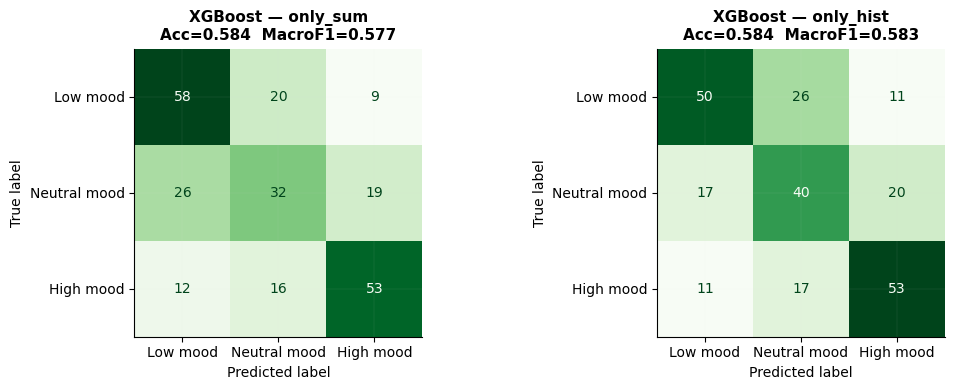

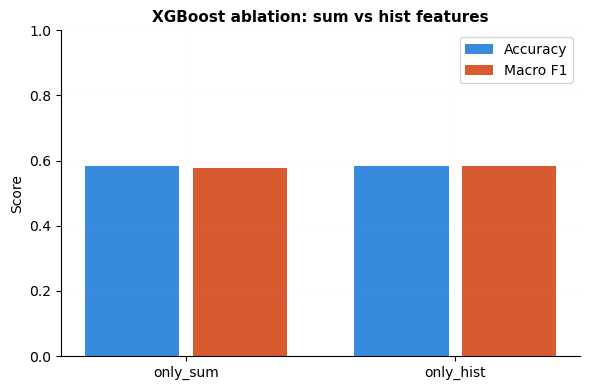

In [37]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, res) in zip(axes, results_xgb.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=class_names,
        cmap="Greens", ax=ax, colorbar=False)
    ax.set_title(f"XGBoost — {name}\n"
                 f"Acc={res['test_acc']:.3f}  MacroF1={res['test_f1']:.3f}")
plt.tight_layout()
plt.savefig("figures/xgb_ablation_confusion.png", dpi=150)
plt.show()

# summary bar chart
fig, ax = plt.subplots(figsize=(6, 4))
names = list(results_xgb.keys())
x     = np.arange(len(names))
ax.bar(x - 0.2, [results_xgb[n]["test_acc"] for n in names], 0.35,
       label="Accuracy", color=BLUE)
ax.bar(x + 0.2, [results_xgb[n]["test_f1"]  for n in names], 0.35,
       label="Macro F1", color=CORAL)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("XGBoost ablation: sum vs hist features")
ax.legend(); plt.tight_layout()
plt.savefig("figures/xgb_ablation_summary.png", dpi=150)
plt.show()

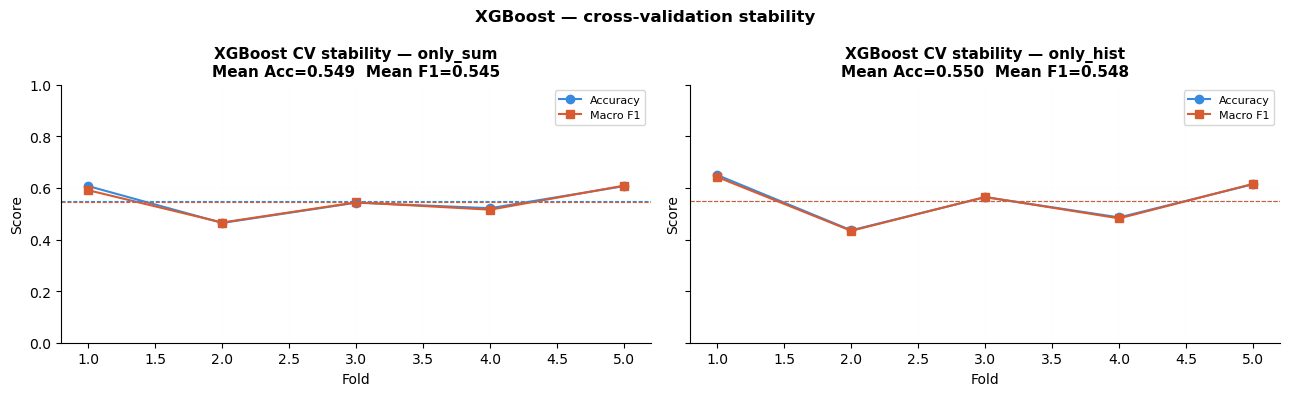

In [55]:
# CV stability plot — both feature sets side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (name, res) in zip(axes, results_xgb.items()):
    fold_accs = res["fold_accs"]
    fold_f1s  = res["fold_f1s"]

    ax.plot(range(1, 6), fold_accs, marker="o", color=BLUE,  label="Accuracy")
    ax.plot(range(1, 6), fold_f1s,  marker="s", color=CORAL, label="Macro F1")
    ax.axhline(np.mean(fold_accs), ls="--", color=BLUE,  lw=0.8)
    ax.axhline(np.mean(fold_f1s),  ls="--", color=CORAL, lw=0.8)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Score")
    ax.set_title(f"XGBoost CV stability — {name}\n"
                 f"Mean Acc={np.mean(fold_accs):.3f}  Mean F1={np.mean(fold_f1s):.3f}")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle("XGBoost — cross-validation stability", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/xgb_cv_stability.png", dpi=150)
plt.show()

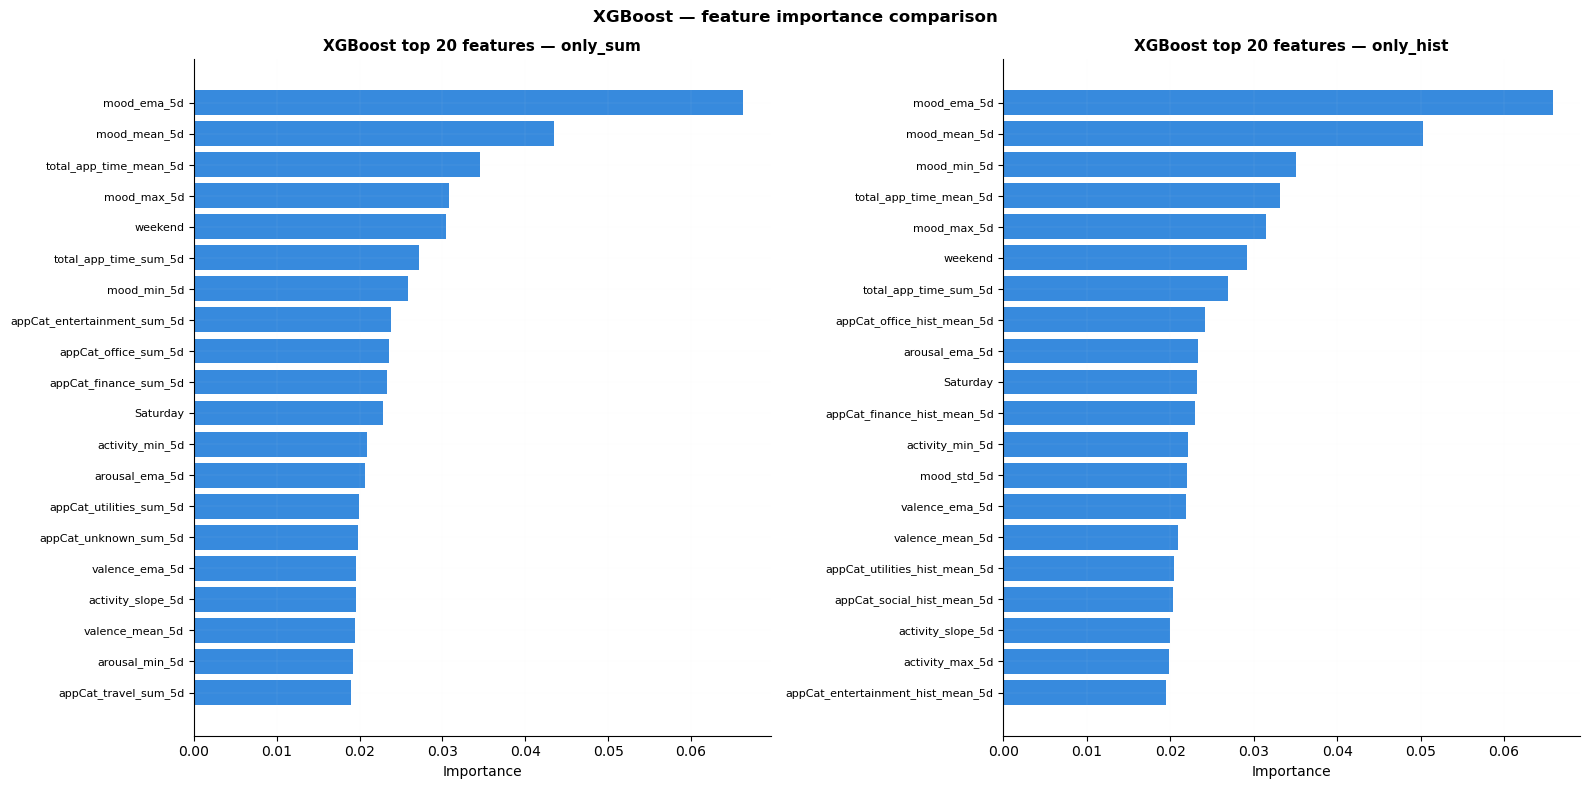

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
 
for ax, (name, res) in zip(axes, results_xgb.items()):
    importances   = res["model"].feature_importances_
    feature_names = list(res["X_train"].columns)  # get names from the training data
 
    # sort and take top 20
    indices = np.argsort(importances)[-20:]
    top_names = [feature_names[i] for i in indices]
    top_vals  = importances[indices]
 
    ax.barh(range(len(top_names)), top_vals, color=BLUE)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title(f"XGBoost top 20 features — {name}")
 
plt.suptitle("XGBoost — feature importance comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/xgb_feature_importance.png", dpi=150)
plt.show()

 ### b) LSTM classifier

In [63]:
# Feature sets for ablation study
base_cols = list(dict.fromkeys(
    [c for c in df_feature.columns
     if any(s in c for s in ["mean","std","weekend","total_app_time"])]
    + [d for d in days   if d in df_feature.columns]
    + [m for m in months if m in df_feature.columns]
))
# remove leakage candidates
base_cols = [c for c in base_cols
             if c not in ("target_mood","mood_next","id","date")]

hist_cols_feat = [c for c in df_feature.columns if c.endswith("_hist")] + ['call_sum', 'screen_sum', 'sms_sum']
hist_cols_nn      = list(dict.fromkeys(base_cols + hist_cols_feat))
sum_cols_feat   = [c for c in df_feature.columns if c.endswith("_sum")]
sum_cols_nn     = list(dict.fromkeys(base_cols + sum_cols_feat))

FEATURE_SETS = {
    "with_hist":    hist_cols_nn,
    "with_sum":     sum_cols_nn,
}
print(f"Sum: {len(sum_cols_nn)} features  |  Hist: {len(hist_cols_nn)} features")

Sum: 34 features  |  Hist: 34 features


In [64]:
# Helper functions (shared by classification and regression LSTM)

def build_sequences_cls(df, seq_cols, window, q33, q66):
    """3D sequences with quantile-based class labels."""
    X_seq, y_seq, groups = [], [], []
    for pid, grp in df.groupby("id"):
        grp  = grp.sort_values("date").reset_index(drop=True)
        vals = grp[seq_cols].fillna(0).values
        for t in range(window, len(grp)):
            X_seq.append(vals[t - window : t])
            y_seq.append(grp["mood_mean"].iloc[t])
            groups.append(pid)
    y_raw = np.array(y_seq)
    y_cls = pd.cut(y_raw, bins=[-np.inf, q33, q66, np.inf],
                   labels=[0,1,2]).astype(int)
    return np.array(X_seq), y_cls, np.array(groups)


def temporal_split(X, y, groups, train_r=0.70, val_r=0.15):
    """Per-patient temporal split → train / val / test."""
    tr_X, tr_y, val_X, val_y, te_X, te_y = [], [], [], [], [], []
    for pid in np.unique(groups):
        idx       = np.where(groups == pid)[0]
        n         = len(idx)
        tr_end    = int(n * train_r)
        val_end   = int(n * (train_r + val_r))
        tr_X.extend(X[idx[:tr_end]]);         tr_y.extend(y[idx[:tr_end]])
        val_X.extend(X[idx[tr_end:val_end]]); val_y.extend(y[idx[tr_end:val_end]])
        te_X.extend(X[idx[val_end:]]);         te_y.extend(y[idx[val_end:]])
    return (np.array(tr_X), np.array(tr_y),
            np.array(val_X), np.array(val_y),
            np.array(te_X),  np.array(te_y))


def scale_sequences(X_tr, X_val, X_te):
    n_steps, n_feats = X_tr.shape[1], X_tr.shape[2]
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr.reshape(-1,n_feats)).reshape(-1,n_steps,n_feats)
    X_val_sc= sc.transform(X_val.reshape(-1,n_feats)).reshape(-1,n_steps,n_feats)
    X_te_sc = sc.transform(X_te.reshape(-1,n_feats)).reshape(-1,n_steps,n_feats)
    return X_tr_sc, X_val_sc, X_te_sc, sc

In [65]:
# LSTM classification model
def build_model_cls(n_steps, n_feats, units, dropout, lr, l2_reg=0.01):
    model = Sequential([
        Input(shape=(n_steps, n_feats)),
        LSTM(units, return_sequences=False, kernel_regularizer=l2(l2_reg)),
        Dropout(dropout),
        Dense(max(8, units // 2), activation="relu", kernel_regularizer=l2(l2_reg)),
        Dropout(dropout * 0.75),
        Dense(3, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [66]:
# Grid search for classification LSTM
PARAM_GRID_CLS = {
    "units":      [16, 32],
    "dropout":    [0.25, 0.4],
    "lr":         [0.001, 0.0005],
    "batch_size": [16, 32],
    "l2_reg":     [0.001, 0.01],
}

def run_search_cls(X_tr, y_tr, X_val, y_val, seed=42):
    tf.random.set_seed(seed)
    y_tr_cat  = to_categorical(y_tr,  3)
    y_val_cat = to_categorical(y_val, 3)
    n_steps, n_feats = X_tr.shape[1], X_tr.shape[2]

    # class weights for imbalanced val folds
    cw     = compute_class_weight("balanced", classes=np.array([0,1,2]), y=y_tr)
    cw_dict = {0: cw[0], 1: cw[1], 2: cw[2]}

    best_acc   = 0
    best_model = best_params = best_history = None
    combos     = [dict(zip(PARAM_GRID_CLS.keys(), v))
                  for v in itertools.product(*PARAM_GRID_CLS.values())]
    print(f"  Trying {len(combos)} combinations...")

    for i, p in enumerate(combos):
        model = build_model_cls(n_steps, n_feats,
                                p["units"], p["dropout"], p["lr"], p["l2_reg"])
        history = model.fit(
            X_tr, y_tr_cat,
            validation_data=(X_val, y_val_cat),
            epochs=80, batch_size=p["batch_size"],
            class_weight=cw_dict,
            callbacks=[EarlyStopping(monitor="val_loss", patience=10,
                                     restore_best_weights=True, verbose=0)],
            verbose=0,
        )
        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        acc    = accuracy_score(y_val, y_pred)
        f1     = f1_score(y_val, y_pred, average="macro")
        print(f"  [{i+1}/{len(combos)}] {p} → Acc={acc:.3f} MacroF1={f1:.3f}")

        if acc > best_acc:
            best_acc     = acc
            best_model   = model
            best_params  = p
            best_history = history

    print(f"\n  Best: {best_params}  Acc={best_acc:.3f}")
    return best_model, best_params, best_history, best_acc

In [67]:
# Run experiment for both feature sets
lstm_window  = 7
results_cls  = {}

for name, features in FEATURE_SETS.items():
    print(f"\n{'='*60}\n LSTM Classification — {name}\n{'='*60}")

    X, y_cls, groups = build_sequences_cls(
        df_feature, features, lstm_window, q33, q66)
    X_tr, y_tr, X_val, y_val, X_te, y_te = temporal_split(X, y_cls, groups)
    X_tr, X_val, X_te, scaler_lstm = scale_sequences(X_tr, X_val, X_te)

    print(f"  Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_te)}")

    model, params, history, best_acc = run_search_cls(X_tr, y_tr, X_val, y_val)

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)

    results_cls[name] = {
        "model":    model,
        "params":   params,
        "history":  history,
        "y_te":     y_te,
        "y_pred":   y_pred,
        "test_acc": accuracy_score(y_te, y_pred),
        "test_f1":  f1_score(y_te, y_pred, average="macro"),
        "scaler":   scaler_lstm,
        "X_te":     X_te,
    }

    # save best model
    model.save(f"models/lstm_cls_{name}.keras")
    joblib.dump(scaler_lstm, f"models/lstm_cls_{name}_scaler.pkl")
    print(f"  Test Acc={results_cls[name]['test_acc']:.3f}  "
          f"Test MacroF1={results_cls[name]['test_f1']:.3f}")


 LSTM Classification — with_hist
  Train: 760 | Val: 165 | Test: 175
  Trying 32 combinations...
  [1/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 16, 'l2_reg': 0.001} → Acc=0.582 MacroF1=0.588
  [2/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 16, 'l2_reg': 0.01} → Acc=0.576 MacroF1=0.578
  [3/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 0.001} → Acc=0.570 MacroF1=0.573
  [4/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 0.01} → Acc=0.576 MacroF1=0.573
  [5/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 16, 'l2_reg': 0.001} → Acc=0.558 MacroF1=0.560
  [6/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 16, 'l2_reg': 0.01} → Acc=0.594 MacroF1=0.594
  [7/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.001} → Acc=0.564 MacroF1=0.564
  [8/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.01} → Acc=0.594 Macr

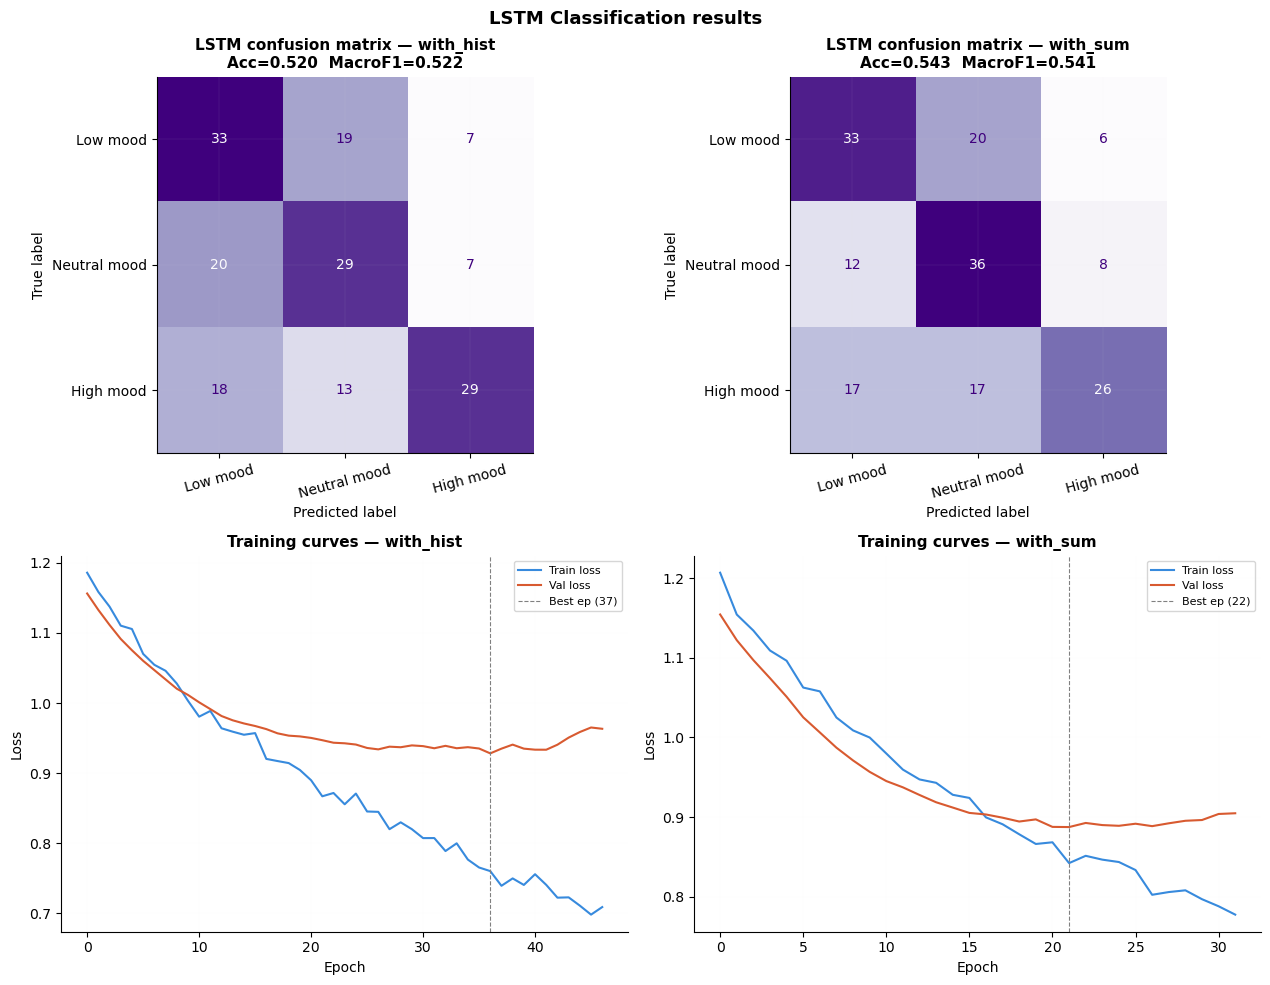

In [68]:
# Evaluation plots for both feature sets
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col_i, (name, res) in enumerate(results_cls.items()):

    # confusion matrix
    ax = axes[0, col_i]
    ConfusionMatrixDisplay.from_predictions(
        res["y_te"], res["y_pred"],
        display_labels=class_names,
        cmap="Purples", ax=ax, colorbar=False)
    ax.set_title(f"LSTM confusion matrix — {name}\n"
                 f"Acc={res['test_acc']:.3f}  MacroF1={res['test_f1']:.3f}")
    ax.tick_params(axis="x", rotation=15)

    # training curves
    ax   = axes[1, col_i]
    hist = res["history"].history
    ep   = np.argmin(hist["val_loss"])
    ax.plot(hist["loss"],     color=BLUE,  label="Train loss")
    ax.plot(hist["val_loss"], color=CORAL, label="Val loss")
    ax.axvline(ep, color="gray", ls="--", lw=0.8, label=f"Best ep ({ep+1})")
    ax.set_title(f"Training curves — {name}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8)

plt.suptitle("LSTM Classification results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lstm_cls_results.png", dpi=150)
plt.show()

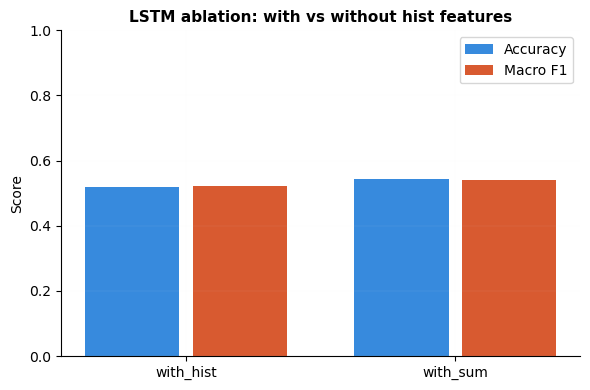


Best feature set: with_sum
              precision    recall  f1-score   support

    Low mood       0.53      0.56      0.55        59
Neutral mood       0.49      0.64      0.56        56
   High mood       0.65      0.43      0.52        60

    accuracy                           0.54       175
   macro avg       0.56      0.55      0.54       175
weighted avg       0.56      0.54      0.54       175



In [69]:
# Ablation summary + per-class report for best model
fig, ax = plt.subplots(figsize=(6, 4))
names_lst = list(results_cls.keys())
accs  = [results_cls[n]["test_acc"] for n in names_lst]
f1s   = [results_cls[n]["test_f1"]  for n in names_lst]
x     = np.arange(len(names_lst))
ax.bar(x - 0.2, accs, 0.35, label="Accuracy", color=BLUE)
ax.bar(x + 0.2, f1s,  0.35, label="Macro F1", color=CORAL)
ax.set_xticks(x); ax.set_xticklabels(names_lst)
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("LSTM ablation: with vs without hist features")
ax.legend(); plt.tight_layout()
plt.savefig("figures/lstm_cls_ablation.png", dpi=150)
plt.show()

best_cls_name = max(results_cls, key=lambda k: results_cls[k]["test_acc"])
print(f"\nBest feature set: {best_cls_name}")
print(classification_report(results_cls[best_cls_name]["y_te"],
                             results_cls[best_cls_name]["y_pred"],
                             target_names=class_names))

## 4 - Numerical Prediction

 ### a) XGBoost Regressor

In [70]:
df_ml_reg = df_ml.copy()
X_reg = df_ml_reg.drop(columns=["id","date","target_mood","mood_class"])
y_reg = df_ml_reg["target_mood"]

train_idx_r, test_idx_r = [], []
for pid, grp in df_ml_reg.groupby("id"):
    grp   = grp.sort_values("date")
    split = int(len(grp) * 0.8)
    train_idx_r.extend(grp.index[:split].tolist())
    test_idx_r.extend(grp.index[split:].tolist())

X_train_r = X_reg.loc[train_idx_r]; y_train_r = y_reg.loc[train_idx_r]
X_test_r  = X_reg.loc[test_idx_r];  y_test_r  = y_reg.loc[test_idx_r]

groups_train_r = df_ml_reg.loc[train_idx_r, "id"].values
custom_cv_r    = list(group_time_series_split(groups_train_r, n_splits=5))

param_grid_reg = {
    "model__max_depth":     [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators":  [100, 200, 300, 500],
    "model__subsample":     [0.8, 1.0],
}

pipe_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  xgb.XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse", random_state=1)),
])

random_search_reg = RandomizedSearchCV(
    estimator=pipe_reg, param_distributions=param_grid_reg,
    n_iter=50, cv=custom_cv_r, scoring="r2",
    random_state=1, n_jobs=-1, verbose=1,
)
random_search_reg.fit(X_train_r, y_train_r)
print(f"\nBest params: {random_search_reg.best_params_}")
print(f"Best CV R² : {random_search_reg.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best CV R² : 0.253


In [71]:
# 5-fold CV stability
best_params_reg = {k.replace("model__",""):v
                   for k,v in random_search_reg.best_params_.items()}

fold_scores_reg = {"r2":[], "rmse":[], "mae":[]}

for fold, (tr_idx, val_idx) in enumerate(custom_cv_r):
    X_tr  = X_train_r.iloc[tr_idx];  y_tr  = y_train_r.iloc[tr_idx]
    X_val = X_train_r.iloc[val_idx]; y_val = y_train_r.iloc[val_idx]

    sc_f   = StandardScaler()
    X_tr_s = sc_f.fit_transform(X_tr)
    X_vl_s = sc_f.transform(X_val)

    fold_reg = xgb.XGBRegressor(
        **best_params_reg, objective="reg:squarederror",
        eval_metric="rmse", random_state=1)
    fold_reg.fit(X_tr_s, y_tr)
    y_vp = fold_reg.predict(X_vl_s)

    fold_scores_reg["r2"].append(r2_score(y_val, y_vp))
    fold_scores_reg["rmse"].append(np.sqrt(mean_squared_error(y_val, y_vp)))
    fold_scores_reg["mae"].append(mean_absolute_error(y_val, y_vp))
    print(f"Fold {fold+1} — R²={fold_scores_reg['r2'][-1]:.3f}  "
          f"RMSE={fold_scores_reg['rmse'][-1]:.3f}  "
          f"MAE={fold_scores_reg['mae'][-1]:.3f}")

print(f"\nMean R²  : {np.mean(fold_scores_reg['r2']):.3f} ± {np.std(fold_scores_reg['r2']):.3f}")
print(f"Mean RMSE: {np.mean(fold_scores_reg['rmse']):.3f} ± {np.std(fold_scores_reg['rmse']):.3f}")
print(f"Mean MAE : {np.mean(fold_scores_reg['mae']):.3f} ± {np.std(fold_scores_reg['mae']):.3f}")

Fold 1 — R²=0.317  RMSE=0.540  MAE=0.423
Fold 2 — R²=0.146  RMSE=0.647  MAE=0.483
Fold 3 — R²=0.222  RMSE=0.639  MAE=0.462
Fold 4 — R²=0.297  RMSE=0.645  MAE=0.450
Fold 5 — R²=0.282  RMSE=0.608  MAE=0.454

Mean R²  : 0.253 ± 0.062
Mean RMSE: 0.616 ± 0.041
Mean MAE : 0.454 ± 0.019


── XGBoost Regressor — test set ──
MAE : 0.438
RMSE: 0.602
MSE : 0.363
R²  : 0.371


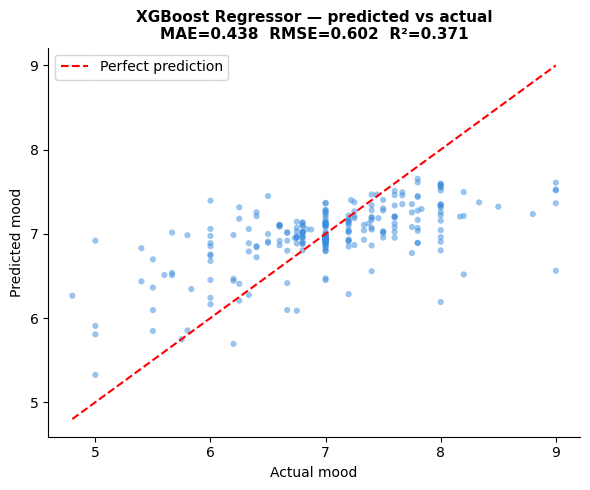

['models/xgboost_regressor_scaler.pkl']

In [72]:
# Final model + evaluation
sc_reg_final     = StandardScaler()
X_train_reg_sc   = sc_reg_final.fit_transform(X_train_r)
X_test_reg_sc    = sc_reg_final.transform(X_test_r)

final_reg = xgb.XGBRegressor(
    **best_params_reg, objective="reg:squarederror",
    eval_metric="rmse", random_state=1)
final_reg.fit(X_train_reg_sc, y_train_r)
y_pred_reg = final_reg.predict(X_test_reg_sc)

mae_xgb  = mean_absolute_error(y_test_r, y_pred_reg)
mse_xgb  = mean_squared_error(y_test_r,  y_pred_reg)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test_r, y_pred_reg)

print("── XGBoost Regressor — test set ──")
print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"MSE : {mse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

# predicted vs actual
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_r, y_pred_reg, alpha=0.5, color=BLUE, edgecolors="none", s=20)
lims = [min(y_test_r.min(), y_pred_reg.min()), max(y_test_r.max(), y_pred_reg.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual mood"); ax.set_ylabel("Predicted mood")
ax.set_title(f"XGBoost Regressor — predicted vs actual\n"
             f"MAE={mae_xgb:.3f}  RMSE={rmse_xgb:.3f}  R²={r2_xgb:.3f}")
ax.legend(); plt.tight_layout()
plt.savefig("figures/xgb_reg_pred_vs_actual.png", dpi=150)
plt.show()

joblib.dump(final_reg,    "models/xgboost_regressor.pkl")
joblib.dump(sc_reg_final, "models/xgboost_regressor_scaler.pkl")

 ### b) LSTM Regressor

In [73]:
def build_sequences_reg(df, seq_cols, window):
    """3D sequences with continuous mood target."""
    X_seq, y_seq, groups = [], [], []
    for pid, grp in df.groupby("id"):
        grp  = grp.sort_values("date").reset_index(drop=True)
        vals = grp[seq_cols].fillna(0).values
        for t in range(window, len(grp)):
            X_seq.append(vals[t - window : t])
            y_seq.append(grp["mood_mean"].iloc[t])
            groups.append(pid)
    return np.array(X_seq), np.array(y_seq), np.array(groups)


def build_model_reg(n_steps, n_feats, units, dropout, lr, l2_reg=0.01):
    model = Sequential([
        Input(shape=(n_steps, n_feats)),
        LSTM(units, return_sequences=False, kernel_regularizer=l2(l2_reg)),
        Dropout(dropout),
        Dense(max(8, units // 2), activation="relu", kernel_regularizer=l2(l2_reg)),
        Dropout(dropout * 0.75),
        Dense(1, activation="linear"),    # continuous output
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

In [74]:
# Full grid search for regression LSTM
PARAM_GRID_REG = {
    "units":      [16, 32],
    "dropout":    [0.25, 0.4],
    "lr":         [0.001, 0.0005],
    "batch_size": [16, 32],
    "l2_reg":     [0.001, 0.01],
}

def run_search_reg(X_tr, y_tr, X_val, y_val, seed=42):
    tf.random.set_seed(seed)
    n_steps, n_feats = X_tr.shape[1], X_tr.shape[2]

    best_mae   = np.inf
    best_model = best_params = best_history = None
    combos = [dict(zip(PARAM_GRID_REG.keys(), v))
              for v in itertools.product(*PARAM_GRID_REG.values())]
    print(f"  Trying {len(combos)} combinations...")

    for i, p in enumerate(combos):
        model = build_model_reg(n_steps, n_feats,
                                p["units"], p["dropout"], p["lr"], p["l2_reg"])
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=80, batch_size=p["batch_size"],
            callbacks=[EarlyStopping(monitor="val_loss", patience=10,
                                     restore_best_weights=True, verbose=0)],
            verbose=0,
        )
        y_pred_val = model.predict(X_val, verbose=0).flatten()
        val_mae    = mean_absolute_error(y_val, y_pred_val)
        val_rmse   = np.sqrt(mean_squared_error(y_val, y_pred_val))
        print(f"  [{i+1}/{len(combos)}] {p} → MAE={val_mae:.3f} RMSE={val_rmse:.3f}")

        if val_mae < best_mae:
            best_mae     = val_mae
            best_model   = model
            best_params  = p
            best_history = history

    print(f"\n  Best: {best_params}  Val MAE={best_mae:.3f}")
    return best_model, best_params, best_history, best_mae

In [75]:
# Run for both feature sets
results_reg = {}

for name, features in FEATURE_SETS.items():
    features = list(dict.fromkeys(features))
    print(f"\n{'='*60}\n LSTM Regression — {name}\n{'='*60}")

    X, y_cont, groups = build_sequences_reg(df_feature, features, lstm_window)
    X_tr, y_tr, X_val, y_val, X_te, y_te = temporal_split(X, y_cont, groups)
    X_tr, X_val, X_te, sc_reg = scale_sequences(X_tr, X_val, X_te)

    print(f"  Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_te)}")

    model, params, history, best_mae = run_search_reg(X_tr, y_tr, X_val, y_val)

    y_pred = model.predict(X_te, verbose=0).flatten()
    mae    = mean_absolute_error(y_te, y_pred)
    mse    = mean_squared_error(y_te,  y_pred)
    r2     = r2_score(y_te, y_pred)

    results_reg[name] = {
        "model":   model, "params": params, "history": history,
        "y_te":    y_te,  "y_pred": y_pred,
        "mae":     mae,   "mse":    mse,
        "rmse":    np.sqrt(mse), "r2": r2,
    }
    model.save(f"models/lstm_reg_{name}.keras")
    joblib.dump(sc_reg, f"models/lstm_reg_{name}_scaler.pkl")
    print(f"  MAE={mae:.3f}  RMSE={np.sqrt(mse):.3f}  R²={r2:.3f}")


 LSTM Regression — with_hist
  Train: 760 | Val: 165 | Test: 175
  Trying 32 combinations...
  [1/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 16, 'l2_reg': 0.001} → MAE=0.613 RMSE=0.729
  [2/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 16, 'l2_reg': 0.01} → MAE=0.512 RMSE=0.649
  [3/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 0.001} → MAE=0.540 RMSE=0.680
  [4/32] {'units': 16, 'dropout': 0.25, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 0.01} → MAE=0.586 RMSE=0.719
  [5/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 16, 'l2_reg': 0.001} → MAE=0.491 RMSE=0.646
  [6/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 16, 'l2_reg': 0.01} → MAE=0.601 RMSE=0.746
  [7/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.001} → MAE=0.759 RMSE=0.933
  [8/32] {'units': 16, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.01} → MAE=0.653 RMSE=0.873
  [9/32] {'units':

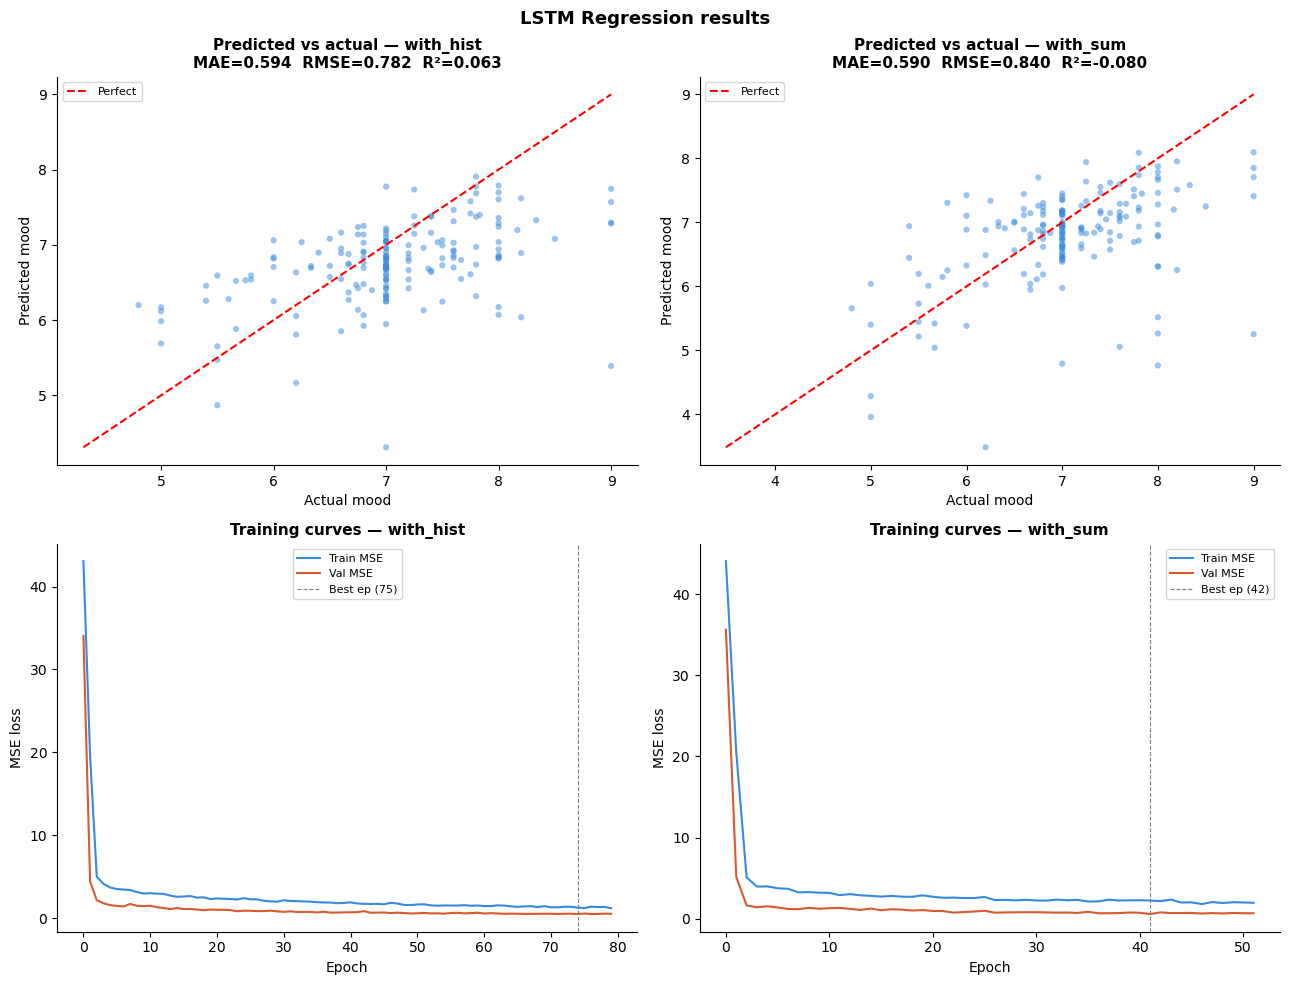

In [76]:
# Regression evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col_i, (name, res) in enumerate(results_reg.items()):
    # predicted vs actual
    ax = axes[0, col_i]
    ax.scatter(res["y_te"], res["y_pred"],
               alpha=0.5, color=BLUE, edgecolors="none", s=20)
    lims = [min(res["y_te"].min(), res["y_pred"].min()),
            max(res["y_te"].max(), res["y_pred"].max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
    ax.set_xlabel("Actual mood"); ax.set_ylabel("Predicted mood")
    ax.set_title(f"Predicted vs actual — {name}\n"
                 f"MAE={res['mae']:.3f}  RMSE={res['rmse']:.3f}  R²={res['r2']:.3f}")
    ax.legend(fontsize=8)

    # training curves
    ax   = axes[1, col_i]
    hist = res["history"].history
    ep   = np.argmin(hist["val_loss"])
    ax.plot(hist["loss"],     color=BLUE,  label="Train MSE")
    ax.plot(hist["val_loss"], color=CORAL, label="Val MSE")
    ax.axvline(ep, color="gray", ls="--", lw=0.8, label=f"Best ep ({ep+1})")
    ax.set_title(f"Training curves — {name}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss"); ax.legend(fontsize=8)

plt.suptitle("LSTM Regression results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lstm_reg_results.png", dpi=150)
plt.show()

 ## 5B - MSE vs MAE comparison

In [ ]:
# Pick best LSTM regression model
best_reg_name = min(results_reg, key=lambda k: results_reg[k]["mae"]) ### CHANGE THIS TO XGB REGRESSOR ACTUALLY

res = results_reg[best_reg_name]
residuals = res["y_te"] - res["y_pred"]

print(f"Best model   : LSTM ({best_reg_name})")
print(f"MAE          : {res['mae']:.4f}  ← mean of |residuals|")
print(f"MSE          : {res['mse']:.4f}  ← mean of residuals²")
print(f"RMSE         : {res['rmse']:.4f} ← √MSE")
print(f"MSE/MAE ratio: {res['mse']/res['mae']:.3f}  "
      f"(>1 → MSE impacted by outliers)")

Best model   : LSTM (with_sum)
MAE          : 0.5896  ← mean of |residuals|
MSE          : 0.7052  ← mean of residuals²
RMSE         : 0.8398 ← √MSE
MSE/MAE ratio: 1.196  (>1 → MSE impacted by outliers)


In [ ]:
print("── Task 5B: MSE vs MAE ──")
print(f"{'Model':<25} {'MAE':>6} {'MSE':>7} {'RMSE':>7} {'MSE/MAE':>8}")
print(f"{'XGBoost':<25} {mae_xgb:>6.3f} {mse_xgb:>7.3f} {rmse_xgb:>7.3f} {mse_xgb/mae_xgb:>8.3f}")
for name, res in results_reg.items():
    ratio = res['mse'] / res['mae']
    print(f"{'LSTM ('+name+')':<25} {res['mae']:>6.3f} {res['mse']:>7.3f} {res['rmse']:>7.3f} {ratio:>8.3f}")

In [78]:
# Summary table: XGBoost vs LSTM regression
print("\n── Regression model comparison ──")
print(f"{'Model':<25} {'MAE':>6} {'RMSE':>7} {'R²':>6}")
print(f"{'XGBoost Regressor':<25} {mae_xgb:>6.3f} {rmse_xgb:>7.3f} {r2_xgb:>6.3f}")
for name, res in results_reg.items():
    print(f"{'LSTM ('+name+')':<25} {res['mae']:>6.3f} {res['rmse']:>7.3f} {res['r2']:>6.3f}")


── Regression model comparison ──
Model                        MAE    RMSE     R²
XGBoost Regressor          0.438   0.602  0.371
LSTM (with_hist)           0.594   0.782  0.063
LSTM (with_sum)            0.590   0.840 -0.080


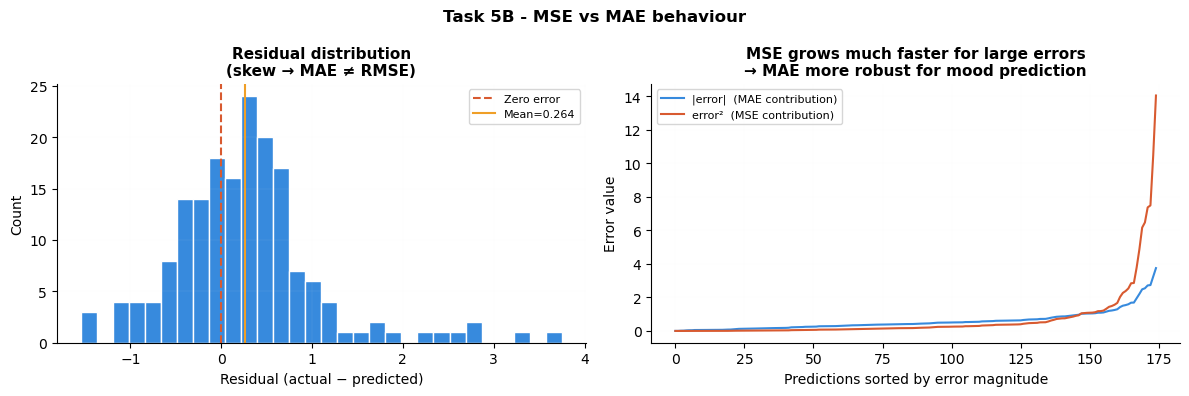

In [79]:
# Task 5B plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# residual distribution
ax = axes[0]
ax.hist(residuals, bins=30, color=BLUE, edgecolor="white")
ax.axvline(0,                color=CORAL, lw=1.5, ls="--", label="Zero error")
ax.axvline(residuals.mean(), color=AMBER, lw=1.5, ls="-",
           label=f"Mean={residuals.mean():.3f}")
ax.set_xlabel("Residual (actual − predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution\n(skew → MAE ≠ RMSE)")
ax.legend(fontsize=8)

# MAE vs MSE contribution per prediction (sorted by error size)
ax = axes[1]
abs_err = np.abs(residuals)
sq_err  = residuals ** 2
idx_s   = np.argsort(abs_err)
ax.plot(abs_err[idx_s], color=BLUE,  lw=1.5, label="|error|  (MAE contribution)")
ax.plot(sq_err[idx_s],  color=CORAL, lw=1.5, label="error²  (MSE contribution)")
ax.set_xlabel("Predictions sorted by error magnitude")
ax.set_ylabel("Error value")
ax.set_title("MSE grows much faster for large errors\n"
             "→ MAE more robust for mood prediction")
ax.legend(fontsize=8)

plt.suptitle("Task 5B - MSE vs MAE behaviour", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/task5b_mse_vs_mae.png", dpi=150)
plt.show()

## References

- papers on same dataset: https://www.jmir.org/2016/3/e72/ (feature engineering), http://link.springer.com/10.1007/978-3-319-39687-3_4 (where data comes from)
- https://www.sciencedirect.com/science/article/pii/S187705091931405X?via%3Dihub Feature engineering, LSTM explanation
- https://ieeexplore.ieee.org/document/10780658/ (maybe) pipeline and architecture (kfold) 
- https://www.nature.com/articles/s41746-024-01035-6 (maybe) interpretation
- https://asu.elsevierpure.com/en/publications/moodscope-building-a-mood-sensor-from-smartphone-usage-patterns/ cited by professor research, definition of circumplex model, feature engineering, multiple linear regression + feature selection
- https://arxiv.org/abs/2012.02359 classes definition, preprocessing
- https://ieeexplore.ieee.org/document/9176242/ other imputation technique: soft-impute (matrix), use of weather data, LSTM for predicting new users’ wellbeing 
- [2202.03721](https://arxiv.org/pdf/2202.03721) (very) useful for preprocessing, imputation, train test split, graphs, NN, multiple linear regression


## Annas Notes 15/04
- need to check (AI) the whole code for inconsistencies 
- LSTM TAKES A LOT OF TIME!!
- better performance with balanced classes? since we have to define them, splitting by quantiles might show that we have more knowledge on how alogirthms work
- added "histogram" relative values to CLASSIFICATION (not regression, also might not be needed because of how the tree works) tree, performance does not improve much with absolute / relative classes (also, + find ways to plot features for XGBboost)
- do we need scaling in classification?
- are we missing anything from the lectures material? measures, ...
- does the MSE vs MAE part make sense?
- once we have a final version, we can reuse the models weights for re running since they are now saved in models folder (not sure how tho)
- some papers also try to check whether we can have good estimates of mood only with appCat categories, could be an extension to our project (not needed)
- start drafting the report with above ref